# Laplace Smoothing (Add-$\alpha$ Smoothing)

## Learning Objectives
- Identify the **zero-frequency problem**: why MLE assigns zero probability to unseen events and why this is catastrophic
- Understand Laplace smoothing as **MAP estimation** with a uniform Dirichlet prior
- Apply the add-$\alpha$ formula correctly for **categorical**, **Bernoulli**, and **multinomial** distributions — noting how the denominator differs in each case
- Understand how $\alpha$ controls the **bias-variance trade-off**: small $\alpha$ trusts data, large $\alpha$ shrinks toward uniform
- Recognise Laplace smoothing as a prerequisite for Bernoulli NB and Multinomial NB

## Quick overview — never assign probability *exactly zero* to an unseen event

If a word, category, or symbol **never appeared** in training, MLE gives it probability `0` — and one zero
multiplies the whole product of probabilities to zero (catastrophic for Naive Bayes, n-gram models, …).

**Laplace / add-α smoothing** fixes this by pretending we saw every category α extra times:

$$\hat p_i = \dfrac{c_i + \alpha}{N + \alpha K}$$

The picture: a category with `c=0` jumps from `0` to a small but **non-zero** probability, while well-attested categories are barely affected.


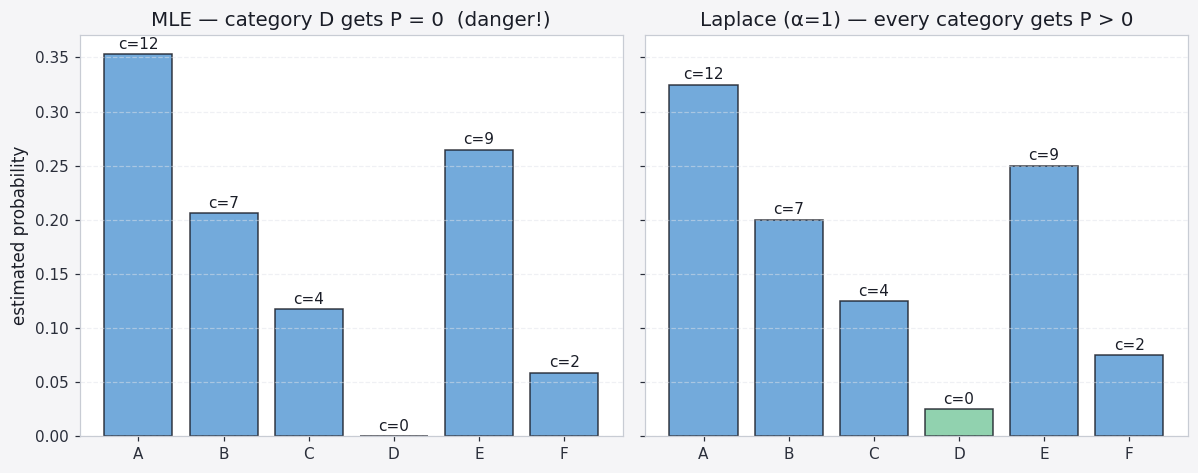

In [1]:
# (quick-overview schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':13,'axes.labelsize':11,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
# counts over K=6 categories, one of them unseen
labels = ['A','B','C','D','E','F']
counts = np.array([12, 7, 4, 0, 9, 2])
N, K = counts.sum(), len(counts)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)

# MLE
ax = axes[0]
p_mle = counts / N
bars = ax.bar(labels, p_mle, color=[P[1] if c==0 else P[0] for c in counts], alpha=0.85, edgecolor='#1a1d27')
ax.set_title('MLE — category D gets P = 0  (danger!)')
ax.set_ylabel('estimated probability'); ax.grid(True, axis='y')
for b, c in zip(bars, counts):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'c={c}', ha='center', fontsize=10)

# Laplace
ax = axes[1]
alpha = 1.0
p_lap = (counts + alpha) / (N + alpha*K)
bars = ax.bar(labels, p_lap, color=[P[3] if c==0 else P[0] for c in counts], alpha=0.85, edgecolor='#1a1d27')
ax.set_title(f'Laplace (α=1) — every category gets P > 0')
ax.grid(True, axis='y')
for b, c in zip(bars, counts):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'c={c}', ha='center', fontsize=10)

plt.tight_layout(); plt.show()


## The Zero-Frequency Problem

### MLE from counts

Given $n$ i.i.d. observations of a categorical variable $X$ taking values in $\{v_1, \ldots, v_V\}$, the **MLE** for the probability of outcome $v_j$ is simply the relative frequency:

$$\hat{P}_{\text{MLE}}(X = v_j) = \frac{c_j}{n}$$

where $c_j = \#\{i : x^{(i)} = v_j\}$ is the count of outcome $v_j$ in the data.

---

### Why this is catastrophic for unseen events

If outcome $v_j$ never appears in the training set, then $c_j = 0$ and:

$$\hat{P}_{\text{MLE}}(X = v_j) = 0$$

Any model that multiplies probabilities (e.g. Naive Bayes) will assign **exactly zero probability** to any test example that contains $v_j$ — regardless of all other features. One unseen word kills the entire document score.

$$P(x \mid y=k) = \prod_{j=1}^{n} P(x_j \mid y=k) \xrightarrow{\text{one } P = 0} 0$$

This is the **zero-frequency problem** (also called the sparse data problem).

---

### Illustrative example

Suppose we train a spam classifier on 100 emails. The word *"bitcoin"* appears 0 times in ham emails.

| Word | Count in ham | MLE $\hat{P}(\text{word} \mid \text{ham})$ |
|---|---|---|
| "free" | 12 | 0.12 |
| "meeting" | 35 | 0.35 |
| **"bitcoin"** | **0** | **0.00** |

A new ham email containing the word "bitcoin" for the first time gets posterior score $0$ for ham — it will be misclassified as spam with certainty, no matter how many other ham-like words it contains.

## Laplace Smoothing — The Fix

### Core idea

Add a **pseudo-count** $\alpha > 0$ to every outcome's count before normalising. This ensures no probability is ever exactly zero.

$$\boxed{\hat{P}_{\text{Laplace}}(X = v_j) = \frac{c_j + \alpha}{\displaystyle n + \alpha V}}$$

where:
- $c_j$ — observed count of outcome $v_j$
- $n = \sum_j c_j$ — total observations
- $V$ — number of distinct outcomes (vocabulary / alphabet size)
- $\alpha$ — smoothing strength ($\alpha = 1$: add-one / Laplace smoothing; any $\alpha > 0$: add-$\alpha$ smoothing)

The denominator adds $\alpha V$ (one $\alpha$ per outcome) to keep probabilities summing to 1:

$$\sum_{j=1}^{V} \hat{P}_{\text{Laplace}}(X = v_j) = \frac{\sum_j (c_j + \alpha)}{n + \alpha V} = \frac{n + \alpha V}{n + \alpha V} = 1 \checkmark$$

---

### Revisiting the example

| Word | Count in ham | MLE | Laplace ($\alpha=1$, $V=3$) |
|---|---|---|---|
| "free" | 12 | 0.12 | $(12+1)/(100+3) \approx 0.126$ |
| "meeting" | 35 | 0.35 | $(35+1)/(100+3) \approx 0.350$ |
| **"bitcoin"** | **0** | **0.00** | $(0+1)/(100+3) \approx \mathbf{0.010}$ |

No probability is zero. The unseen word gets a small but non-zero probability proportional to $\alpha / (n + \alpha V)$.

---

### Effect of $\alpha$

| $\alpha$ | Behaviour |
|---|---|
| $\alpha \to 0$ | Recovers MLE — probabilities approach raw frequencies |
| $\alpha = 1$ | Add-one smoothing — the standard default |
| $\alpha \to \infty$ | Shrinks all probabilities toward uniform: $\hat{P}(v_j) \to 1/V$ |

Increasing $\alpha$ **reduces variance** (less sensitive to individual counts) at the cost of **increased bias** (pushes toward uniform, ignoring the data).

## Why This Works — MAP with a Dirichlet Prior

Laplace smoothing is not arbitrary — it is exactly **MAP estimation** (maximum a posteriori) when the prior over the probability vector is a **symmetric Dirichlet** distribution.

---

### Bayesian view

Let $\theta = (\theta_1, \ldots, \theta_V)$ be the true probabilities, with $\sum_j \theta_j = 1$.

**Prior:** place a symmetric Dirichlet prior on $\theta$:

$$\theta \sim \text{Dir}(\alpha, \alpha, \ldots, \alpha), \qquad p(\theta) \propto \prod_{j=1}^{V} \theta_j^{\alpha - 1}$$

**Likelihood:** the observed counts $(c_1, \ldots, c_V)$ follow a multinomial:

$$p(c \mid \theta) \propto \prod_{j=1}^{V} \theta_j^{c_j}$$

**Posterior:** by conjugacy, the posterior is also Dirichlet:

$$\theta \mid c \sim \text{Dir}(\alpha + c_1,\; \alpha + c_2,\; \ldots,\; \alpha + c_V)$$

**MAP estimate** (mode of the Dirichlet):

$$\hat{\theta}^{\text{MAP}}_j = \frac{(\alpha + c_j) - 1}{\sum_{j'} [(\alpha + c_{j'}) - 1]} = \frac{c_j + \alpha - 1}{n + \alpha V - V}$$

For $\alpha = 1$ this recovers MLE exactly (uniform prior, mode = MLE). For $\alpha > 1$ this is the Laplace formula with $(\alpha - 1)$ in place of $\alpha$.

> **Convention note:** In ML practice the formula $\dfrac{c_j + \alpha}{n + \alpha V}$ is used universally (it corresponds to the **posterior mean**, not the mode). It equals MLE when $\alpha = 0$ and equals the uniform prior $1/V$ when $n = 0$.

---

### Summary of the probabilistic interpretation

| Estimator | Formula | Prior |
|---|---|---|
| MLE | $c_j / n$ | No prior (uniform improper prior, $\alpha \to 0$) |
| Laplace smoothing (mean) | $(c_j + \alpha) / (n + \alpha V)$ | Symmetric $\text{Dir}(\alpha)$ prior |
| Uniform | $1/V$ | Infinite-strength prior ($n \to 0$ or $\alpha \to \infty$) |

The pseudo-count $\alpha$ encodes **prior belief**: "before seeing any data, act as if each outcome was already seen $\alpha$ times."

## Formula Variants Across Distributions

The denominator changes depending on how many outcomes can occur — the key rule is: **add $\alpha$ once per possible outcome**.

---

### Categorical / Multinomial (V outcomes)

$$\hat{P}(X = v_j) = \frac{c_j + \alpha}{n + \alpha V}$$

Used in **Multinomial Naive Bayes** for word probabilities.

---

### Bernoulli (2 outcomes: 0 and 1)

$$\hat{P}(X = 1 \mid y=k) = \frac{c_{k1} + \alpha}{m_k + 2\alpha}$$

where $c_{k1}$ = count of feature being 1 in class $k$, $m_k$ = total examples in class $k$. Denominator uses $2\alpha$ because there are exactly 2 Bernoulli outcomes.

Used in **Bernoulli Naive Bayes**.

---

### Multinomial NB (word counts, vocabulary size $V$)

$$\hat{\phi}_{kj} = \frac{\displaystyle\sum_{i:\, y^{(i)}=k} x^{(i)}_j + \alpha}{\displaystyle\sum_{j'=1}^{V}\sum_{i:\, y^{(i)}=k} x^{(i)}_{j'} + \alpha V}$$

Numerator: total count of word $j$ in class $k$ plus pseudo-count. Denominator: total word count in class $k$ plus $\alpha V$ (one $\alpha$ per vocabulary word).

---

### Quick reference

| Distribution | Outcomes | Denominator |
|---|---|---|
| Categorical | $V$ | $n + \alpha V$ |
| Bernoulli | $2$ | $m_k + 2\alpha$ |
| Multinomial NB | $V$ (vocab) | $\sum_j c_{kj} + \alpha V$ |

## Key Properties

| Property | Detail |
|---|---|
| **Guarantees** | All estimated probabilities $> 0$; still sum to 1 |
| **Reduces to MLE** | When $\alpha \to 0$ (or equivalently $n \gg \alpha V$, data dominates) |
| **Reduces to uniform** | When $n \to 0$ (no data) or $\alpha \to \infty$ |
| **Probabilistic interpretation** | Posterior mean under a symmetric $\text{Dir}(\alpha)$ prior |
| **Bias-variance** | Higher $\alpha$ → higher bias, lower variance |
| **Does NOT apply to Gaussian NB** | Gaussian NB uses a variance floor $+\,\varepsilon$ instead — smoothing of a continuous density is a different problem |
| **Downstream use** | Always work in **log-space** after smoothing: $\log \hat{P}$ never hits $-\infty$ |